<a href="https://colab.research.google.com/github/khushi78vaish/smart_homes_energy_consumption/blob/main/energy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 import numpy as np
import pandas as pd
import random
import math
import time
import matplotlib.pyplot as plt
from copy import deepcopy

- **Name**: name of appliance
- **Type**: non-shiftable (NS), power-shiftable operable at different power levels (PS), time-shiftable operable at any time slot within normal working slots (TS)
- **Diss.Coeff.**: dissatisfaction coefficient / factor determining weightage of deviation from maximum power level for power shiftable appliances and from earliest normal working slot (waiting time) for time shiftable appliances
- **Power rating**: appliance's power levels
- **Time Slot**: normal working slots for each appliance

In [ ]:
num_slots = 8

In [ ]:
appliance_data = [['Ref', 'NS', 100, 0.5, [1, num_slots]], ['AS', 'NS', 100, 0.1, [1, num_slots]],
                  ['AC1', 'PS', 0.05, [0.7, 1.4, 0.1], [1, num_slots]], ['AC2', 'PS', 50, [0.7, 1.4, 0.1], [1, num_slots]],
                  ['H', 'PS', 0.12, [0.5, 1.5, 0.1], [1, num_slots]],
                  ['L1', 'PS', 20, [0.2, 0.6, 0.1], [5, 7]],
                  ['L2', 'PS', 0.03, [0.2, 0.6, 0.1], [5, 7]],
                  ['WM', 'TS', 0.1, 0.7, [6, 8]],
                  ['DW', 'TS', 0.06, 0.3, [6, 8]]]

appliance_df = pd.DataFrame(appliance_data, columns=['Name', 'Type', 'Diss. Coeff.', 'Power Rating (kWh)', 'Time Slot'])
appliance_df

appliance_df = appliance_df.sort_values('Diss. Coeff.', ascending = False)
appliance_df

,Name,Type,Diss. Coeff.,Power Rating (kWh),Time Slot
0,Ref,NS,100.00,0.5,"[1, 8]"
1,AS,NS,100.00,0.1,"[1, 8]"
3,AC2,PS,50.00,"[0.7, 1.4, 0.1]","[1, 8]"
5,L1,PS,20.00,"[0.2, 0.6, 0.1]","[5, 7]"
4,H,PS,0.12,"[0.5, 1.5, 0.1]","[1, 8]"
7,WM,TS,0.10,0.7,"[6, 8]"
8,DW,TS,0.06,0.3,"[6, 8]"
2,AC1,PS,0.05,"[0.7, 1.4, 0.1]","[1, 8]"
6,L2,PS,0.03,"[0.2, 0.6, 0.1]","[5, 7]"


# Electricity Price Generation

In [ ]:
ep_mx_q1 = 35
ep_mx_q2 = 35
ep_mx_q3 = 30
ep_mx_q4 = 20
ep_k = 5
min_price = 7

<Figure size 640x480 with 0 Axes>

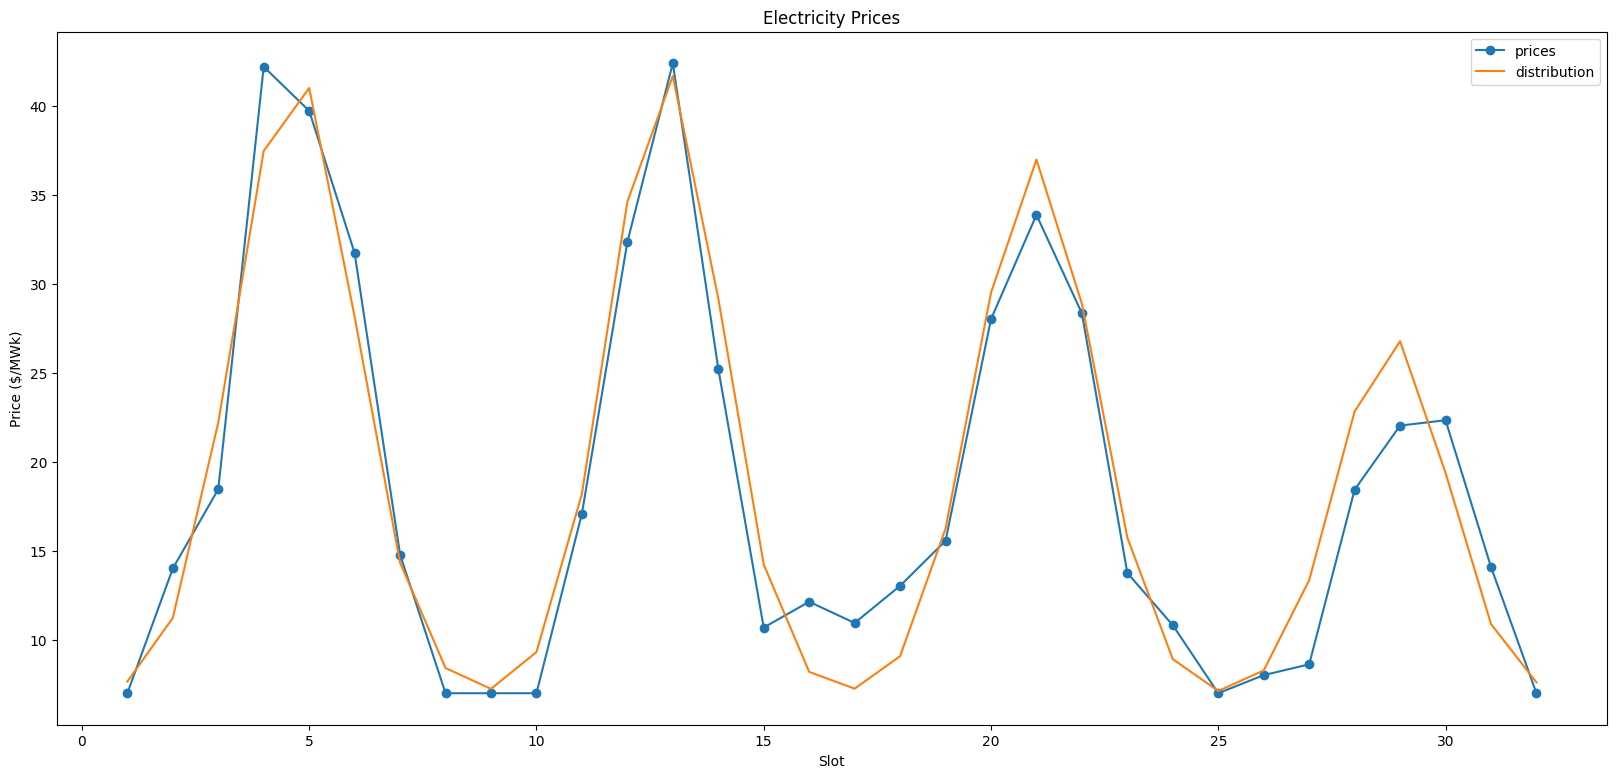

In [ ]:
num_points = 1000

mu, sigma = 0, 1.0/(np.sqrt(2 * np.pi) * ep_mx_q1)
s = np.random.normal(mu, sigma, num_points)
count, bins, ignored = plt.hist(s, num_slots, density=True)
plt.clf()
electricity_prices = [max(0, 1/(sigma * np.sqrt(2 * np.pi)) * np.exp( - (i - mu)**2 / (2 * sigma**2)) + random.uniform(-ep_k, ep_k)) for i in bins[:-1]]
distribution = [1/(sigma * np.sqrt(2 * np.pi)) * np.exp( - (i - mu)**2 / (2 * sigma**2)) for i in bins[:-1]]

mu, sigma = 0, 1.0/(np.sqrt(2 * np.pi) * ep_mx_q2)
s = np.random.normal(mu, sigma, num_points)
count, bins, ignored = plt.hist(s, num_slots, density=True)
plt.clf()
electricity_prices += [max(0, 1/(sigma * np.sqrt(2 * np.pi)) * np.exp( - (i - mu)**2 / (2 * sigma**2)) + random.uniform(-ep_k, ep_k)) for i in bins[:-1]]
distribution += [1/(sigma * np.sqrt(2 * np.pi)) * np.exp( - (i - mu)**2 / (2 * sigma**2)) for i in bins[:-1]]

mu, sigma = 0, 1.0/(np.sqrt(2 * np.pi) * ep_mx_q3)
s = np.random.normal(mu, sigma, num_points)
count, bins, ignored = plt.hist(s, num_slots, density=True)
plt.clf()
electricity_prices += [max(0, 1/(sigma * np.sqrt(2 * np.pi)) * np.exp( - (i - mu)**2 / (2 * sigma**2)) + random.uniform(-ep_k, ep_k)) for i in bins[:-1]]
distribution += [1/(sigma * np.sqrt(2 * np.pi)) * np.exp( - (i - mu)**2 / (2 * sigma**2)) for i in bins[:-1]]

mu, sigma = 0, 1.0/(np.sqrt(2 * np.pi) * ep_mx_q4)
s = np.random.normal(mu, sigma, num_points)
count, bins, ignored = plt.hist(s, num_slots, density=True)
plt.clf()
electricity_prices += [max(0, 1/(sigma * np.sqrt(2 * np.pi)) * np.exp( - (i - mu)**2 / (2 * sigma**2)) + random.uniform(-ep_k, ep_k)) for i in bins[:-1]]
distribution += [1/(sigma * np.sqrt(2 * np.pi)) * np.exp( - (i - mu)**2 / (2 * sigma**2)) for i in bins[:-1]]

electricity_prices = [i + min_price for i in electricity_prices]
distribution = [i + min_price for i in distribution]

slots = range(1, 4*num_slots+1)
f = plt.figure()
f.set_figwidth(20)
f.set_figheight(9)
plt.title("Electricity Prices")
plt.xlabel("Slot")
plt.ylabel("Price ($/MWk)")
plt.plot(slots, electricity_prices, "-o", label = "prices")
plt.plot(slots, distribution, label = "distribution")
plt.legend()
plt.show()

# Multi-Agent Q Learning

Agents take that action which maximizes their own expected cumulative reward.

In [ ]:
cols = ['Name', 'Type', 'Diss. Coeff.', 'Power Rating (kWh)', 'Time Slot']

def get_reward_DR(st, t, agent, act, started):
    reward = 0.0
    cost = 0.0
    agent_data = appliance_df.loc[appliance_df['Name'] == agent]
    if (agent_data['Type'] == 'NS').bool():
        ts = agent_data['Time Slot'].tolist()[0]
        if in_slot(t, ts):
            pr = agent_data['Power Rating (kWh)'].tolist()[0]
            reward = (-st[0] * max(0, (pr)))
            cost = (-st[0] * max(0, (pr)))
    elif (agent_data['Type'] == 'PS').bool():
        ts = agent_data['Time Slot'].tolist()[0]
        if in_slot(t, ts):
            pr = agent_data['Power Rating (kWh)'].tolist()[0]
            dc = agent_data['Diss. Coeff.'].tolist()[0]
            reward = ((-st[0] * max(0, (act))) - (dc * math.pow(pr[1] - act, 2)))
            cost = (-st[0] * max(0, (act)))
    elif (agent_data['Type'] == 'TS').bool():
        ts = agent_data['Time Slot'].tolist()[0]
        if in_slot(t, ts):
            pr = agent_data['Power Rating (kWh)'].tolist()[0]
            dc = agent_data['Diss. Coeff.'].tolist()[0]
            if (act == 'on' or (t + 1 == ts[1])) and started[agent] != 1:
                reward = - (st[0] * max(0, pr) - (dc * math.pow(ts[0] - t - 1, 2)))
                cost = (-st[0] * max(0, (pr)))
                started[agent] = 1
    return round(reward, 6), cost, started

def get_reward_without_DR(st, t, agent):
    reward = 0.0
    cost = 0.0
    agent_data = appliance_df.loc[appliance_df['Name'] == agent]
    if (agent_data['Type'] == 'NS').bool():
        ts = agent_data['Time Slot'].tolist()[0]
        if in_slot(t, ts):
            pr = agent_data['Power Rating (kWh)'].tolist()[0]
            reward = (-st[0] * max(0, (pr)))
            cost = (-st[0] * max(0, (pr)))
    elif (agent_data['Type'] == 'PS').bool():
        ts = agent_data['Time Slot'].tolist()[0]
        if in_slot(t, ts):
            pr = agent_data['Power Rating (kWh)'].tolist()[0]
            reward = (-st[0] * max(0, (pr[1])))
            cost = (-st[0] * max(0, (pr[1])))

    elif (agent_data['Type'] == 'TS').bool():
        ts = agent_data['Time Slot'].tolist()[0]
        if in_slot(t, ts):
            pr = agent_data['Power Rating (kWh)'].tolist()[0]
            if t + 1 == ts[0]:
                reward = - (st[0] * max(0, pr))
                cost = - (st[0] * max(0, pr))
    return round(reward, 6), cost


started = {}
for agents in agent:
        started[agent] = 0
print(get_reward_DR(states[6], 6, 'WM', 'on', started))
print(get_reward_without_DR(states[6], 6, 'WM'))

NameError: name 'agent' is not defined

In [ ]:
num_timeslots = num_slots
num_episodes = 1000
epsilon = 0.3

gamma = 0.9
theta = 0.3

converged = 1
threshold = 0.001

recommendations = {}
actually_started = {}

for t in range(num_timeslots):
    actually_started[t] = {}
    for agent in agents:
        actually_started[t][agent] = 0

started = {}
for agent in agents:
        started[agent] = 0

Without_DR_total_reward = 0.0
With_DR_total_reward = 0.0

Without_DR_total_electricity_cost = 0.0
With_DR_total_electricity_cost = 0.0

average_time = 0

for t in range(num_timeslots):
    print('Slot: ', t + 1)
    start = time.time()
    recommendations[t] = {}
    Q = {}
    Q_prev = {}
    R = {}
    C = {}
    for st in states:
        Q[st] = {}
        Q_prev[st] = {}
        R[st] = {}
        C[st] = {}
        for agent in agents:
            Q[st][agent] = {}
            Q_prev[st][agent] = {}
            R[st][agent] = {}
            C[st][agent] = {}
            recommendations[t][agent] = None
    converged = 1
    for agent in agents:
        print('Appliance: ', agent)
        for st in states:
            for act in agent_actions[agent]:
                Q[st][agent][act] = 0.0
                Q_prev[st][agent][act] = 0.0
        if t > 0:
            started[agent] = actually_started[t - 1][agent]
        else:
            started[agent] = 0
        for eps in range(num_episodes):
            if t > 0:
                if actually_started[t-1][agent] != 1:
                    started[agent] = 0
            else:
                started[agent] = 0
            Q_prev = deepcopy(Q)
            st = states[t]
            itr = 0
            curr_t = t
            while curr_t < num_slots - 1:
                p = np.random.random()
                if p < epsilon:
                    j = np.random.choice(len(agent_actions[agent]))
                else:
                    j = np.argmax([Q[st][agent][a] for a in agent_actions[agent]])
                at = agent_actions[agent][j]
                sdash = states[curr_t + 1]
                R[st][agent][at], C[st][agent][at], started = get_reward_DR(st, curr_t, agent, at, started)
                Q[st][agent][at] = Q[st][agent][at] + theta * (R[st][agent][at] + gamma * max([Q[sdash][agent][act] for act in agent_actions[agent]]) - Q[st][agent][at])
                st = sdash
                curr_t += 1
            converged = 1
            for s in states:
                for a in agent_actions[agent]:
                    if abs(Q[s][agent][a] - Q_prev[s][agent][a]) > threshold:
                        converged = 0
            if converged == 1:
                conv_eps = eps
                break
        recommendations[t][agent] = agent_actions[agent][np.argmax([Q[states[t]][agent][a] for a in agent_actions[agent]])]
        agent_data = appliance_df.loc[appliance_df['Name'] == agent]
        slot = agent_data['Time Slot'].tolist()[0]
        if not in_slot(t, slot):
            recommendations[t][agent] = None
        if (appliance_df.loc[appliance_df['Name'] == agent]['Type'] == 'TS').bool() and actually_started[t][agent] == 1:
            recommendations[t][agent] = 'off'
        if recommendations[t][agent] == 'on' and (appliance_df.loc[appliance_df['Name'] == agent]['Type'] == 'TS').bool():
            if t + 1 < num_timeslots:
                actually_started[t + 1][agent] = 1
        if recommendations[t][agent] == 'off' and (appliance_df.loc[appliance_df['Name'] == agent]['Type'] == 'TS').bool() and actually_started[t][agent] == 0 and t + 1 ==  slot[1]:
            if t + 1 < num_timeslots:
                actually_started[t + 1][agent] = 1
            recommendations[t][agent] = 'on'
    print(converged)
    end = time.time()
    print('Time taken to recommend (s): ', end-start)
    average_time += (end-start)
    print("Slot: ", t + 1, " | Recommendations: ", recommendations[t])


NameError: name 'agents' is not defined

In [ ]:
Appliance_Without_DR_Cost = {}
Appliance_With_DR_Cost = {}

Timeslot_Without_DR_Cost = {}
Timeslot_With_DR_Cost = {}

Appliance_Without_DR_Reward = {}
Appliance_With_DR_Reward = {}

Without_DR_total_reward = 0
With_DR_total_reward = 0
Without_DR_total_electricity_cost = 0
With_DR_total_electricity_cost = 0

for agent in agents:
    Appliance_Without_DR_Cost[agent] = 0
    Appliance_With_DR_Cost[agent] = 0
    Appliance_Without_DR_Reward[agent] = 0
    Appliance_With_DR_Reward[agent] = 0

for t in range(num_timeslots):
    Timeslot_Without_DR_Cost[t] = 0
    Timeslot_With_DR_Cost[t] = 0
    for agent in agents:
        temp = deepcopy(actually_started)

        rew, c, actually_started[t] = get_reward_DR(states[t], t, agent, recommendations[t][agent], actually_started[t])
        actually_started = temp
        With_DR_total_reward += rew
        Appliance_With_DR_Reward[agent] -= rew
        With_DR_total_electricity_cost += c
        Appliance_With_DR_Cost[agent] -= c
        Timeslot_With_DR_Cost[t] -= c

        rew, c = get_reward_without_DR(states[t], t, agent)
        Without_DR_total_reward += rew
        Appliance_Without_DR_Reward[agent] -= rew
        Without_DR_total_electricity_cost += c
        Appliance_Without_DR_Cost[agent] -= c
        Timeslot_Without_DR_Cost[t] -= c

NameError: name 'agents' is not defined

In [ ]:
for t in range(num_timeslots):
    print("Slot: ", t + 1, " | Recommendations: ", recommendations[t])
    print("Slot: ", t + 1, " | Original Actions: ", without_DR_actions[t])
    print()

KeyError: 0

In [ ]:
from IPython.display import display
recom_data = {}
Recom_df = {}
for agent in agents:
    print('\n\nAppliance: ', agent, ' | Dis. Coef.: ', appliance_df.loc[appliance_df['Name'] == agent]['Diss. Coeff.'].tolist()[0])
    recom_data[agent] = [[t+1, without_DR_actions[t][agent], recommendations[t][agent], states[t][0]] for t in range(num_timeslots)]
    Recom_df[agent] = pd.DataFrame(recom_data[agent], columns=['Slot', 'Action without DR', 'Action with DR', 'Elec. Price ($/MWk)'])
    display(Recom_df[agent])

NameError: name 'agents' is not defined

In [ ]:
states

NameError: name 'states' is not defined

In [ ]:
appliance_df

,Name,Type,Diss. Coeff.,Power Rating (kWh),Time Slot
0,Ref,NS,100.00,0.5,"[1, 8]"
1,AS,NS,100.00,0.1,"[1, 8]"
3,AC2,PS,50.00,"[0.7, 1.4, 0.1]","[1, 8]"
5,L1,PS,20.00,"[0.2, 0.6, 0.1]","[5, 7]"
4,H,PS,0.12,"[0.5, 1.5, 0.1]","[1, 8]"
7,WM,TS,0.10,0.7,"[6, 8]"
8,DW,TS,0.06,0.3,"[6, 8]"
2,AC1,PS,0.05,"[0.7, 1.4, 0.1]","[1, 8]"
6,L2,PS,0.03,"[0.2, 0.6, 0.1]","[5, 7]"


## Assuming Recommendations are followed, cost with and w/o Demand Response

In [ ]:
print('\n\nTotal reward without DR: ', Without_DR_total_reward)
print('Total reward with DR: ', With_DR_total_reward)

print('Total electricity cost without DR: ', -Without_DR_total_electricity_cost)
print('Total electricity cost with DR: ', -With_DR_total_electricity_cost)

print('Average Recommendation Time: ', average_time / num_timeslots)

print()
print()

dc = appliance_df['Diss. Coeff.'].tolist()
DC = {}
i = 0
for agent in agents:
    DC[agent] = dc[i]
    i += 1



Total reward without DR:  0
Total reward with DR:  0
Total electricity cost without DR:  0
Total electricity cost with DR:  0


NameError: name 'average_time' is not defined

In [ ]:
data = [[agent, Appliance_Without_DR_Cost[agent], Appliance_With_DR_Cost[agent], DC[agent], Appliance_Without_DR_Reward[agent], Appliance_With_DR_Reward[agent]] for agent in agents]

data.append(['Total', -Without_DR_total_electricity_cost, -With_DR_total_electricity_cost, '-', Without_DR_total_reward, With_DR_total_reward])
DR_df = pd.DataFrame(data, columns=['Name', 'Cost without DR (cents)', 'Cost with DR (cents)', 'Diss. Coef.', 'Reward without DR', 'Reward with DR'])
DR_df

NameError: name 'agents' is not defined

In [ ]:
ts_data = [[t+1, Timeslot_Without_DR_Cost[t], Timeslot_With_DR_Cost[t], states[t][0], Timeslot_Without_DR_Cost[t]/states[t][0], Timeslot_With_DR_Cost[t]/states[t][0]] for t in range(num_timeslots)]
TS_df = pd.DataFrame(ts_data, columns=['Slot', 'Cost without DR (cents)', 'Cost with DR (cents)', 'Elec. Price ($/MWk)', 'Power Con. without DR (kWh)', 'Power Con. with DR (kWh)'])

TS_df

KeyError: 0

In [ ]:
prices  = []
without_DR = []
with_DR = []
for t in range(num_timeslots):
    prices.append(states[t][0])
    with_DR.append(Timeslot_With_DR_Cost[t])
    without_DR.append(Timeslot_Without_DR_Cost[t])
plt.title('Electricity Cost with and without DR')
plt.xlabel('Slot')
plt.ylabel('Price')
plt.plot(range(num_timeslots), without_DR, label="Cost without DR")
plt.plot(range(num_timeslots), with_DR, label="Cost with DR", color='g')
plt.plot(range(num_timeslots), prices, label="Electricity Prices", color='r')
plt.legend()

NameError: name 'states' is not defined

### Hence, we see a 40-50% cost saving with DR than without DR.